In [27]:
%pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 0.0/100.2 MB 1.3 MB/s eta 0:01:19
   ---------------------------------------- 0.1/100.2 MB 751.6 kB/s eta 0:02:14
   ---------------------------------------- 0.1/100.2 MB 751.6 kB/s eta 0:02:14
   ---------------------------------------- 0.1/100.2 MB 554.9 kB/s eta 0:03:01
   ---------------------------------------- 0.2/100.2 MB 701.4 kB/s eta 0:02:23
   ---------------------------------------- 0.2/100.2 MB 701.4 kB/s eta 0:02:23
   ---------------------------------------- 0.2/100.2 MB 701.4 kB/s eta 0:02:23
   ---------------------------------------- 0.2/100.2 MB 701.4 kB/s eta 0:02:23
   ---------------------------------------- 0.3/100.2 MB 681.0 kB/s eta 0:02:27
   ---------------------------------------- 0.3/100.2 MB 681.0 kB/s eta 0:02:27
   ---------------------------------------- 0.4/100.2


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Importing Libraries :

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score

# Models
import lightgbm as lgb
import xgboost as xgb

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Load Data

In [2]:
train = pd.read_csv('Data/train_data.csv')
test = pd.read_csv('Data/test_data.csv')

print(train.shape, test.shape)
train.head()

(89392, 12) (59595, 11)


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


# Basic EDA

In [3]:
train.info()
train.describe()

# Missing values
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id              89392 non-null  int64
 1   gender          89392 non-null  str  
 2   area            89392 non-null  str  
 3   qualification   89392 non-null  str  
 4   income          89392 non-null  str  
 5   marital_status  89392 non-null  int64
 6   vintage         89392 non-null  int64
 7   claim_amount    89392 non-null  int64
 8   num_policies    89392 non-null  str  
 9   policy          89392 non-null  str  
 10  type_of_policy  89392 non-null  str  
 11  cltv            89392 non-null  int64
dtypes: int64(5), str(7)
memory usage: 8.2 MB


id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

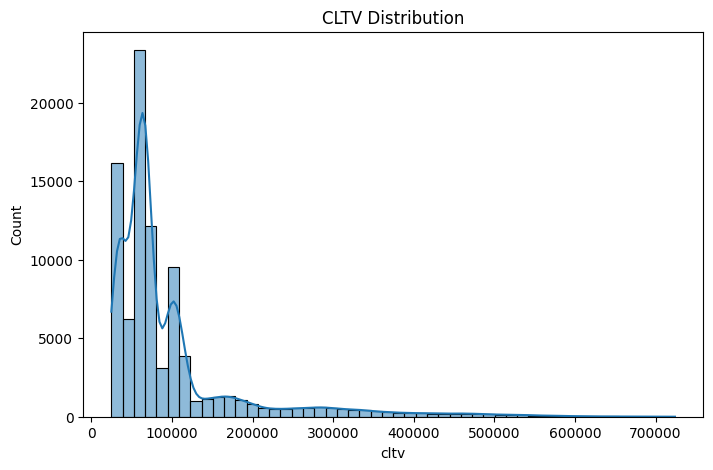

In [4]:
# Target distribution
plt.figure(figsize=(8,5))
sns.histplot(train['cltv'], bins=50, kde=True)
plt.title("CLTV Distribution")
plt.show()

Model Focuses on high-frequency low values , Performs poorly on high CLTV customers .  
Hence , I must transform the target :  
- Why log transform works :  
  - Compresses large values  
  - Reduces skewness  
  - Makes distribution more Gaussian-like  
  - Improves model learning  

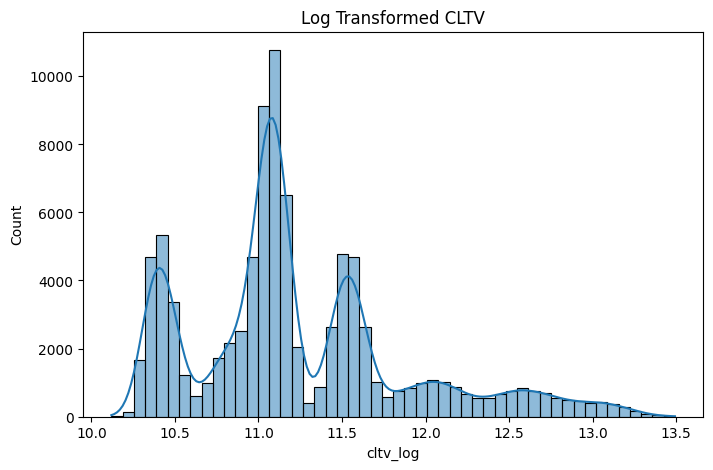

In [5]:
train['cltv_log'] = np.log1p(train['cltv'])
plt.figure(figsize=(8,5))
sns.histplot(train['cltv_log'], bins=50, kde=True)
plt.title("Log Transformed CLTV")
plt.show()

# Feature Engineering

- Feature Understanding

In [6]:
cat_cols = ['gender', 'area', 'qualification', 'policy', 'type_of_policy']
num_cols = ['income', 'vintage', 'claim_amount', 'num_policies']

- Fix "num_policies" column

In [7]:
def map_num_policies(x):
    if x == 'More than 1':
        return 2
    else:
        return int(x)

train['num_policies_num'] = train['num_policies'].apply(map_num_policies)
test['num_policies_num'] = test['num_policies'].apply(map_num_policies)

# Binary feature for multiple policies

train['multi_policy'] = (train['num_policies'] == "More than 1").astype(int)
test['multi_policy'] = (test['num_policies'] == "More than 1").astype(int)
train.drop('num_policies', axis=1, inplace=True)
test.drop('num_policies', axis=1, inplace=True)

- Fix "income" column 
  - Convert to numeric (midpoint encoding)

In [8]:
def income_to_num(x):
    if pd.isnull(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    # Clean formatting issues
    x = x.replace('\n', ' ')
    x = x.replace(' ', '')
    
    # Case 1: <=2L
    if '<=' in x:
        return 1   # midpoint approx
    
    # Case 2: More than 10L
    if 'morethan' in x:
        return 12
    
    # Case 3: Range (e.g., 2L-5L)
    if '-' in x:
        parts = x.replace('l', '').split('-')
        
        if len(parts) == 2:
            try:
                low = float(parts[0])
                high = float(parts[1])
                return (low + high) / 2
            except:
                return np.nan
    
    return np.nan
train['income_num'] = train['income'].apply(income_to_num)
test['income_num'] = test['income'].apply(income_to_num)

train['log_income'] = np.log1p(train['income_num'])
test['log_income'] = np.log1p(test['income_num'])

-
  - Create income category index

In [9]:
income_map = {
    '<=2L': 1,
    '2L-5L': 2,
    '5L-10L': 3,
    'More than 10L': 4
}

train['income_cat'] = train['income'].map(income_map)
test['income_cat'] = test['income'].map(income_map)

- Interaction Features 

In [10]:
def feature_engineering(df):
    
    # Ratio features
    df['income_per_policy'] = df['income_num'] / (df['num_policies_num'] + 1)
    df['claim_per_policy'] = df['claim_amount'] / (df['num_policies_num'] + 1)
    
    # Customer engagement
    df['policy_vintage_ratio'] = df['num_policies_num'] / (df['vintage'] + 1)
    
    # Financial behavior
    df['claim_income_ratio'] = df['claim_amount'] / (df['income_num'] + 1)
    
    # Log transformations
    df['log_income'] = np.log1p(df['income_num'])
    df['log_claim'] = np.log1p(df['claim_amount'])
    
    return df

train = feature_engineering(train)
test = feature_engineering(test)

- Final cleaning

In [11]:
num_cols = train.select_dtypes(include=['float64', 'int64']).columns
num_cols = [col for col in num_cols if col in test.columns]

for col in num_cols:
    median_val = train[col].median()
    train[col].fillna(median_val, inplace=True)
    test[col].fillna(median_val, inplace=True)
print(train.isnull().sum().sum(), test.isnull().sum().sum())

0 0


In [12]:
print("Train null columns:\n")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nTest null columns:\n")
print(test.isnull().sum()[test.isnull().sum() > 0])

Train null columns:

Series([], dtype: int64)

Test null columns:

Series([], dtype: int64)


# Categorical Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['gender', 'area', 'qualification', 'policy', 'type_of_policy']

for col in cat_cols:
    le = LabelEncoder()
    
    combined = pd.concat([train[col], test[col]], axis=0)
    le.fit(combined)
    
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

In [14]:
drop_cols = ['id', 'cltv', 'cltv_log', 'income']

X = train.drop(columns=drop_cols)
y = train['cltv_log']

X_test = test.drop(columns=['id', 'income'])

print(X.shape, X_test.shape)

(89392, 18) (59595, 18)


In [15]:
drop_cols = [
    'multi_policy',              # duplicate info
    'income_cat',               # redundant
    'log_income',               # redundant (only 4 values)
    'claim_income_ratio'        # unstable ratios
]
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [16]:
for col in X.columns:
    print(col, X[col].nunique())

gender 2
area 2
qualification 3
marital_status 2
vintage 9
claim_amount 10889
policy 3
type_of_policy 3
num_policies_num 2
multi_policy 2
income_num 4
log_income 4
income_cat 4
income_per_policy 8
claim_per_policy 14391
policy_vintage_ratio 14
claim_income_ratio 22774
log_claim 10889


In [17]:
print(train['num_policies_num'].value_counts())

num_policies_num
2    60263
1    29129
Name: count, dtype: int64


In [18]:
# Log transform (very important)
train['log_claim'] = np.log1p(train['claim_amount'])
test['log_claim'] = np.log1p(test['claim_amount'])

# Binary signal (important)
train['claim_flag'] = (train['claim_amount'] > 0).astype(int)
test['claim_flag'] = (test['claim_amount'] > 0).astype(int)

In [23]:
train['policy_type'] = train['policy'].astype(str) + "_" + train['type_of_policy'].astype(str)
test['policy_type']  = test['policy'].astype(str) + "_" + test['type_of_policy'].astype(str)

train['income_policy'] = train['income_num'].astype(str) + "_" + train['policy'].astype(str)
test['income_policy']  = test['income_num'].astype(str) + "_" + test['policy'].astype(str)
# Claim intensity
train['claim_to_vintage'] = train['claim_amount'] / (train['vintage'] + 1)
test['claim_to_vintage'] = test['claim_amount'] / (test['vintage'] + 1)

In [24]:
cat_cols = ['policy', 'type_of_policy', 'policy_type', 'income_policy']

for col in cat_cols:
    train[col] = train[col].astype(str)
    test[col] = test[col].astype(str)

In [25]:
features = [
    'income_policy',
    'vintage',
    'claim_amount',
    'log_claim',
    'claim_flag',
    'income_num',
    'policy',
    'type_of_policy',
    'policy_type',
    'claim_to_vintage'
]
X = train[features]
X_test = test[features]
y = train['cltv_log']

# Model Setup ( Catboost for Categorical features )

In [28]:

from catboost import CatBoostRegressor
cat_cols = ['policy', 'type_of_policy']
from sklearn.model_selection import StratifiedKFold

train['bins'] = pd.qcut(train['cltv'], q=5, labels=False)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [29]:
oof = np.zeros(len(X))
preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, train['bins'])):
    
    print(f"\n🚀 Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=3,
        loss_function='RMSE',
        eval_metric='R2',
        random_seed=42,
        verbose=200,
        od_type='Iter',     # early stopping type
        od_wait=200     
    )
    
    model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
        cat_features=cat_cols,
        use_best_model=True
    )
    
    oof[val_idx] = model.predict(X_val)
    preds += model.predict(X_test) / skf.n_splits


🚀 Fold 1


CatBoostError: Bad value for num_feature[non_default_doc_idx=0,feature_idx=0]="7.5_0": Cannot convert '7.5_0' to float

# Model Setup (Tuned LigthGBM)

In [15]:
lgb_params = {
    'n_estimators': 6000,
    'learning_rate': 0.01,
    'max_depth': 6,
    'num_leaves': 64,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'reg_alpha': 1.5,
    'reg_lambda': 1.5,
    'random_state': 42
}

# Cross Validation 

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X))
preds = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    
    print(f"\n🚀 Fold {fold+1}")
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**lgb_params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[
            lgb.early_stopping(200),
            lgb.log_evaluation(200)
        ]
    )
    
    oof[val_idx] = model.predict(X_val)
    preds += model.predict(X_test) / kf.n_splits

# Back-transform
oof_final = np.expm1(oof)
y_true = train['cltv']

print("\n🎯 R2 Score:", r2_score(y_true, oof_final))


🚀 Fold 1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1088
[LightGBM] [Info] Number of data points in the train set: 71513, number of used features: 18
[LightGBM] [Info] Start training from score 11.239210
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -